In [1]:
# @launchit.collected

# Begin

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
from io import BytesIO
import sqlite3

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
import cupy as cp
import pandas as pd
import einops
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn.functional as F

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, '.')) # @launchit.collect
from dataset_utils import *
from samplers import *
sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from hp_utils import *
from image_utils import *
import db_utils
import launchit # @launchit.disable
from autoincrement import Autoincrement

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_sample_01.ipynb',
 'self_name': '15_sample_01',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [4]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    db_fname: str = None
    samplers: list = None
    max_seq_length: int = None
    reset_samples: bool = None
    batch_size: int = None
    batches_count: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

In [5]:
@dataclass
class SamplerParams:
    spec: str = None
    class_name: str = None
    args: list = None
    kwargs: dict = None
    
def hp_parse_samplers(samplers):
    grammar = '''
        spec: SAMPLER_CLASS_NAME ( "(" arg_list_spec ")" )?
        SAMPLER_CLASS_NAME: IDENTIFIER
    
        arg_list_spec: (ARG_VALUE ("," ARG_VALUE)* ("," KWARG_NAME "=" KWARG_VALUE)*)? (KWARG_NAME "=" KWARG_VALUE ("," KWARG_NAME "=" KWARG_VALUE)*)?
        ARG_VALUE: NUMBER | ESCAPED_STRING
        KWARG_NAME: IDENTIFIER
        KWARG_VALUE: NUMBER | ESCAPED_STRING
        IDENTIFIER: LETTER (LETTER|DIGIT|"_")*

        %import common.ESCAPED_STRING
        %import common.LETTER
        %import common.DIGIT
        %import common.NUMBER
        %import common.INT
        %import common.WS
        %ignore WS
    '''
    lark_parser = lark.Lark(grammar, start='spec')
    params_list = []

    for sampler in samplers:
        tree = lark_parser.parse(sampler)
        args, kwargs = parse_arg_list(tree)
        params_list.append(SamplerParams(spec=sampler, class_name=get_lark_tree_value(tree, 'SAMPLER_CLASS_NAME'), args=args, kwargs=kwargs))

    return params_list

In [6]:
hp_parse_samplers(['RandomSampler(123, a=1, b=2, c="cw")'])

[SamplerParams(spec='RandomSampler(123, a=1, b=2, c="cw")', class_name='RandomSampler', args=[123], kwargs={'a': 1, 'b': 2, 'c': 'cw'})]

# Launch

## get_db_con

In [7]:
def get_db_con(hp=None, is_ro=False, autocommit=True):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    full_db_fname = os.path.join(CONFIG.private_data_path, hp.db_fname)

    if is_ro:
        return sqlite3.connect(f'file:{full_db_fname}?mode=ro', uri=True, autocommit=autocommit)
    else:
        return sqlite3.connect(full_db_fname, autocommit=autocommit)

## Bootstrap

In [8]:
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

Random seed=42


# Create samples

## Configure

In [17]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'dataset_5_128.db'
HP.samplers = [
    'SpiralSampler(direction="cw")',
    'SpiralSampler(direction="ccw")',
    'ZigzagSampler()',
]
HP.max_seq_length = 25
HP.reset_samples = True
HP.batch_size = 100
HP.batches_count = 3

## create_sampler

In [18]:
def create_sampler(sampler_params, meta):
    common_params = BaseSampler.CommonParams(
        spec=sampler_params.spec,
        image_size=meta.image_size,
        patch_size=meta.patch_size,
        max_seq_length=HP.max_seq_length,
        rng=RNG,
    )
    
    match sampler_params.class_name:
        case 'LinearRandomSampler': return LinearRandomSampler(common_params, *sampler_params.args, **sampler_params.kwargs)
        case 'SigmoidRandomSampler': return SigmoidRandomSampler(common_params, *sampler_params.args, **sampler_params.kwargs)
        case 'SpiralSampler': return SpiralSampler(common_params, *sampler_params.args, **sampler_params.kwargs)
        case 'ZigzagSampler': return ZigzagSampler(common_params, *sampler_params.args, **sampler_params.kwargs)
        case _: assert False, f'Unsupported {sampler_params.class_name=}'

## Create

In [19]:
with get_db_con(is_ro=True) as db_con:
    meta = load_meta(db_con)
    sampler_params_list = hp_parse_samplers(HP.samplers)
    samplers = [create_sampler(sampler_params, meta) for sampler_params in sampler_params_list]

## Populate

### samplers

In [20]:
with get_db_con(autocommit=True) as db_con:
    if LangUtils.coalesce(HP.reset_samples, False):
        db_utils.drop_table_safe(db_con, 'samplers')

    columns = defaultdict(list)

    for sampler in samplers:
        columns['sampler'].append(sampler.spec)

    df = pd.DataFrame(columns)
    df.index += db_utils.get_max_value(db_con, 'samplers', 'sampler_ind') if db_utils.is_table_exists(db_con, 'samplers') else 0
    df.to_sql('samplers', con=db_con, if_exists='append', index_label='sampler_ind')
    LOG(f'{HP.db_fname}: table "samplers" populated, added {len(df)} rows, total {db_utils.get_rows_count(db_con, 'samplers')} rows')

dataset_5_128.db: table "samplers" populated, added 3 rows, total 3 rows


### samples

In [21]:
with get_db_con(autocommit=False) as db_con:
    if LangUtils.coalesce(HP.reset_samples, False):
        db_utils.drop_table_safe(db_con, 'samples')

    db_con.execute('DROP INDEX IF EXISTS idx_samples_image_ind')

    meta = load_meta(db_con)
    df_vocab_tokens = load_vocab_tokens(db_con)
    df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM encodings', con=db_con)
    batches_count = len(df_image_inds) // HP.batch_size + int(bool(len(df_image_inds) % HP.batch_size))
    batches_count = LangUtils.coalesce(HP.batches_count, batches_count)
    rows_count = 0
    
    for row_ind, batch_ind in tqdm(zip(range(0, len(df_image_inds), HP.batch_size), range(batches_count)), total=batches_count):
        batch_image_inds = df_image_inds.image_ind.iloc[row_ind:row_ind+HP.batch_size].to_numpy()
        columns = defaultdict(list)

        for image_ind in batch_image_inds:
            df_encoding = pd.read_sql(
                'SELECT e.pos_token_ind, e.vocab_token_ind, e.bfr, pt.i, pt.j, pt.i2, pt.j2, pt.center_i, pt.center_j ' + 
                'FROM encodings e, vocab_tokens vt, pos_tokens pt ' +
                'WHERE e.pos_token_ind=pt.token_ind AND e.vocab_token_ind=vt.token_ind AND e.image_ind=:image_ind', 
                con=db_con, 
                params=dict(image_ind=int(image_ind))
            )
            assert len(df_encoding) > 0

            for sampler_ind, sampler in enumerate(samplers):
                sample, cycles_count = sampler(df_encoding)
                sample = ','.join((map(str, sample.ravel())))
                columns['image_ind'].append(image_ind)
                columns['sampler_ind'].append(sampler_ind)
                columns['sample'].append(sample)

        df = pd.DataFrame(columns)
        df.index += db_utils.get_max_value(db_con, 'samples', 'sample_ind') if db_utils.is_table_exists(db_con, 'samples') else 0
        df.to_sql('samples', con=db_con, if_exists='append', index_label='sample_ind')
        db_con.commit()
        rows_count += len(df)

    LOG(f'{HP.db_fname}: table "samples" populated, added {rows_count} rows, total {db_utils.get_rows_count(db_con, 'samples')} rows')

    db_con.execute('CREATE INDEX idx_samples_image_ind ON samples(image_ind)')
    db_con.commit()
    LOG(f'{HP.db_fname}: index "idx_samples_image_ind" created')

  0%|          | 0/3 [00:00<?, ?it/s]

dataset_5_128.db: table "samples" populated, added 900 rows, total 900 rows
dataset_5_128.db: index "idx_samples_image_ind" created


# Verify samples

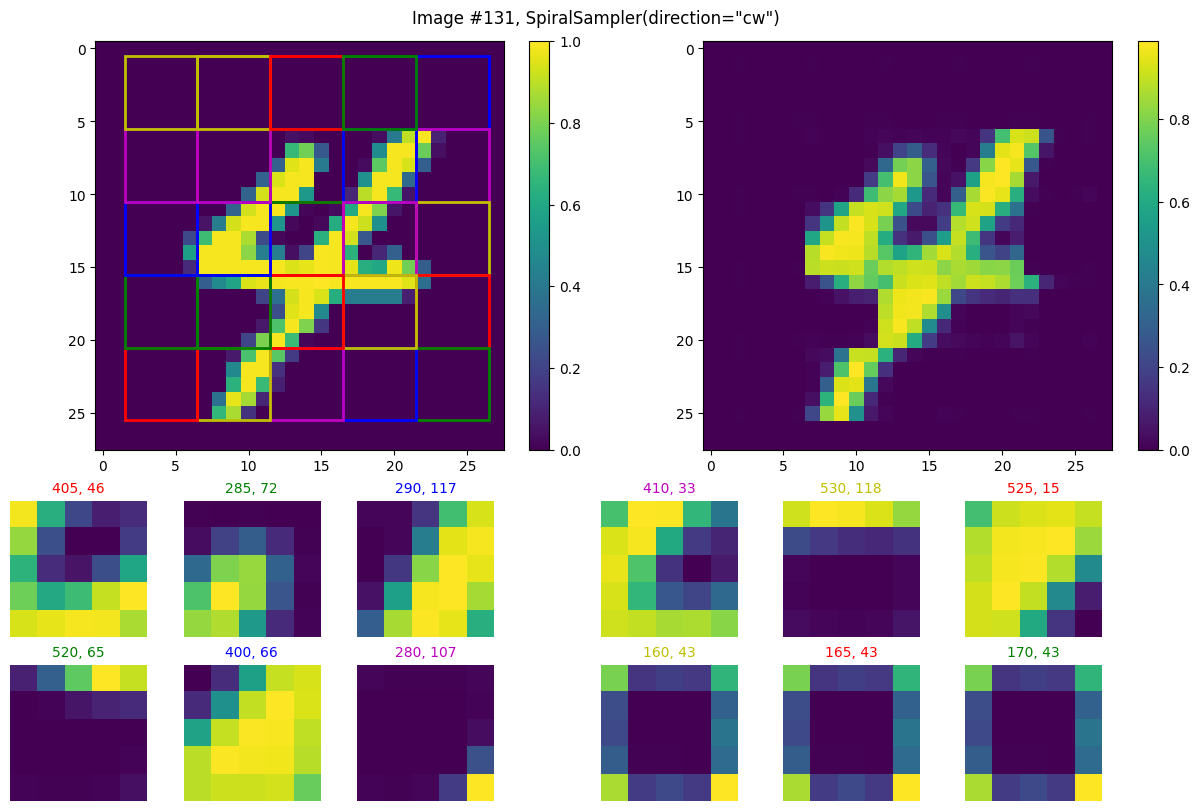

In [24]:
with get_db_con(is_ro=True) as db_con:
    meta = load_meta(db_con)
    df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM samples', con=db_con)
    image_ind = int(RNG.choice(df_image_inds.image_ind))
    # image_ind = 36947
    # image_ind = 16346 # thin 6 which shows poor reconstruction
    df_vocab_tokens = load_vocab_tokens(db_con)
    df_pos_tokens = load_pos_tokens(db_con)
    df_samples = pd.read_sql('SELECT sample, sampler FROM samples s1, samplers s2 WHERE s1.image_ind=? AND s1.sampler_ind=s2.sampler_ind', params=[image_ind], con=db_con)
    sample_row = next(df_samples.itertuples())
    sample, sampler = sample_row.sample, sample_row.sampler
    sample = np.array(list(map(int, sample.split(','))))
    sample = sample.reshape(-1, 2)
    
    fig, axd = plt.subplot_mosaic(
        [
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['C', 'D', 'E', 'F', 'G', 'H'],
            ['I', 'J', 'K', 'L', 'M', 'N'],
        ], 
        layout="constrained"
    )
    fig.set_figwidth(12)
    fig.set_figheight(8)
    image = load_image(image_ind, db_con)
    fig.suptitle(f'Image #{image_ind}, {sampler}')
    im = axd['A'].imshow(image)
    fig.colorbar(im, ax=axd['A'])
    b_image = np.zeros((meta.image_size, meta.image_size))

    for ind, (pos_token_ind, vocab_token_ind) in enumerate(sample):
        color = 'rgbmy'[ind % 5]
        
        df_pos_token = df_pos_tokens[df_pos_tokens.token_ind == pos_token_ind]
        assert len(df_pos_token) == 1
        pt = next(df_pos_token.itertuples())
        rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), meta.patch_size, meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
        axd['A'].add_patch(rect)

        df_vocab_token = df_vocab_tokens[df_vocab_tokens.token_ind == vocab_token_ind]
        assert len(df_vocab_token) == 1
        vt = next(df_vocab_token.itertuples())
        with BytesIO(vt.data) as b: vocab_item = np.load(b)
        b_image[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vocab_item)
    
    im = axd['B'].imshow(b_image)
    fig.colorbar(im, ax=axd['B'])
    
    for ind, ((pos_token_ind, vocab_token_ind), ax_name) in enumerate(zip(sample, 'CDEFGHIJKLMN')):
        color = 'rgbmy'[ind % 5]
        
        df_pos_token = df_pos_tokens[df_pos_tokens.token_ind == pos_token_ind]
        assert len(df_pos_token) == 1
        pt = next(df_pos_token.itertuples())
        rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), meta.patch_size, meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
        axd['A'].add_patch(rect)
        
        df_vocab_token = df_vocab_tokens[df_vocab_tokens.token_ind == vocab_token_ind]
        assert len(df_vocab_token) == 1
        vt = next(df_vocab_token.itertuples())
        with BytesIO(vt.data) as b: vocab_item = np.load(b)
        
        ax = axd[ax_name]
        title = '\n'.join((
            f'{pt.token_ind}, {vt.token_ind}',
        ))
        ax.set_title(title, c=color, fontdict=dict(fontsize=10))
        ax.imshow(ArrayUtils.v2sm(vocab_item))
        ax.set_axis_off()

# LaunchIt!

In [13]:
# @launchit.disable
launchit_t0 = time.time()

In [16]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(CONFIG.model_group_uri))
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars)
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/15_transformer/15_dataset_01-launch8.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_dataset_01-launch8.ipynb"
